# 31 - Normalization: StandardScaler vs MinMaxScaler

**Section:** Metaparameters | **Prereqs:** `FNNs/MinMaxMNIST.ipynb` | **Next:** `Metaparameters/ExploringWineDataSet.ipynb`

Reference notebook for input scaling - the cheapest accuracy improvement in
machine learning, and the one most often skipped.

**Why it matters.** A network's first layer computes `W @ x`. If one feature
ranges over 0-1000 and another over 0-1, the first dominates the sum and its
weight receives gradients a thousand times larger. One learning rate cannot suit
both, so training is slow, unstable, or both.

| | StandardScaler | MinMaxScaler |
|---|---|---|
| Formula | `(x - mean) / std` | `(x - min) / (max - min)` |
| Result | mean 0, std 1 | bounded in [0,1] |
| Outliers | tolerant | one outlier squashes everything else |
| Use when | features are roughly normal | you need a hard bound (images, sigmoids) |

**Fit on train only.** Both scalers *learn* parameters (mean/std, or min/max)
from the data you fit them on. Fitting on the whole dataset before splitting
leaks test statistics into training, so the pattern is always
`scaler.fit_transform(train)` then `scaler.transform(test)`.

**Not the same thing as batch normalisation,** which scales *activations* inside
the network during training - see `Metaparameters/BatchNorm.ipynb`.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# 100 random integers 0-9 as a stand-in feature.
arr = np.random.randint(0,10, size=(100,1))


# StandardScaler

### Why use it?
- Brings every feature to **zero-mean, unit-variance**
- Helps gradient-based optimizers converge faster
- Stops distance-based models from being dominated by large-magnitude features

### Formula  

$$
z_{ij} \;=\; \frac{x_{ij} - \mu_j}{\sigma_j}
$$

where  

- $\displaystyle \mu_j \;=\; \frac{1}{n}\sum_{i=1}^{n} x_{ij}$ — mean of column $j$  
- $\displaystyle \sigma_j \;=\; \sqrt{\frac{1}{n}\sum_{i=1}^{n} (x_{ij}-\mu_j)^2}
$ — standard deviation of column $j$  

#### After scaling, each column has **mean ≈ 0** and **std ≈ 1**.

### **Best practice: Fit the scaler only on the training data, then reuse the learned $\mu_j$ and $\sigma_j$ on validation/test sets to avoid data leakage.**


In [38]:
# Z-score scaling: subtract the mean, divide by the standard deviation.
# fit_transform() = learn (mean, std) then apply. On test data use transform()
# alone, so the training statistics are reused.
# Z score normalization (sklearn standerdization)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(arr)

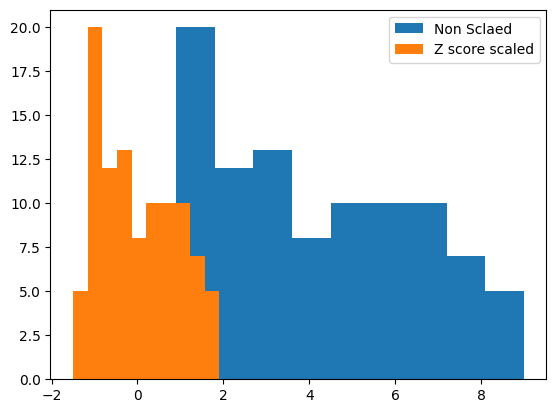

In [39]:
# The histogram shifts and narrows but keeps its SHAPE. Scaling is a change of
# units - it cannot fix a skewed distribution.
plt.hist(arr, label="Non Sclaed");
plt.hist(scaled, label="Z score scaled");
plt.legend();

In [32]:
# Confirms mean 0 and std 1.
# round(), not int(): int() truncates towards zero, so a mean of -0.4 would also
# print as 0 and the check would pass without meaning anything.
round(float(np.mean(scaled)), 6), round(float(np.std(scaled,ddof=1)), 6)

# Standerd dev is 1 and the mean is 0: Confirms that it is z score scaled

(0, 1)

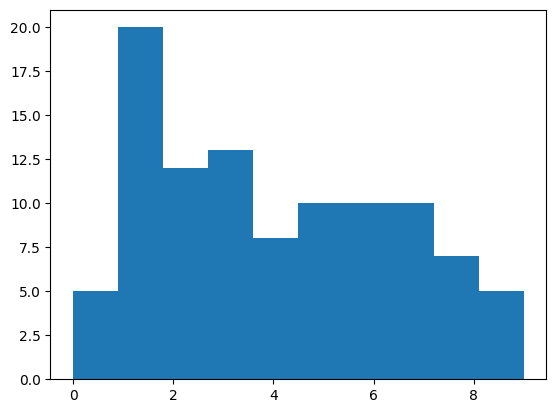

In [40]:
# A different tool: sqrt is a NON-linear transform, which does change the shape
# of the distribution. Used to tame right-skewed features before scaling.
# (The variable is named log_arr but holds a square root.)
log_arr = np.sqrt(arr)
plt.hist(arr);


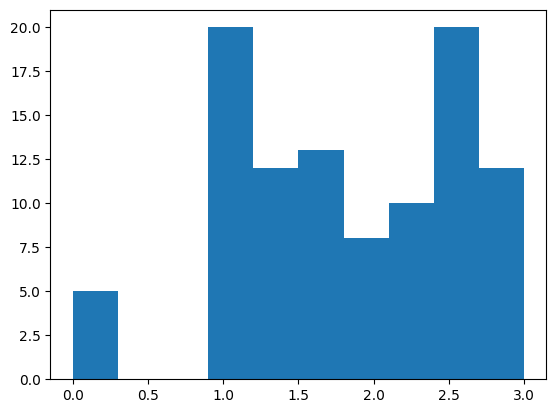

In [42]:
# The square-rooted distribution, visibly less skewed than the original.
plt.hist(log_arr);

#  MinMaxScaler

### Why use it?
- Rescales each feature to a fixed interval (default **[0 , 1]**)
- Preserves the shape of the original distribution (linear transformation)
- Useful for algorithms that assume **bounded** input (e.g., neural nets with sigmoids)

### Formula  

For a desired feature range \([a \, b]\) (default \(a=0 \; b=1\)):

$$
z_{ij} \;=\; \bigl(\tfrac{x_{ij} - x^{\min}_j}{\,x^{\max}_j - x^{\min}_j}\bigr)\,(b - a) \;+\; a
$$

where  

- **Minimum per feature:** $x^{\min}_j = \min_i x_{ij}$  
- **Maximum per feature:** $x^{\max}_j = \max_i x_{ij}$  


With the default settings (\(a = 0 \; b = 1\)), every scaled feature lies in **[0 , 1]**.

## **Best practice:** Fit the scaler **only** on the training data, then reuse the learned $x_{j}^{\min}$ and $x_{j}^{\max}$ to transform validation / test sets — this prevents data leakage.


In [ ]:
# MinMax scaling: map the observed range onto [0,1].
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
MMscaled = scaler.fit_transform(arr)

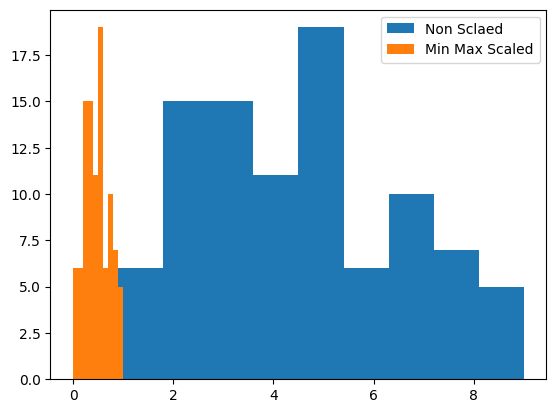

In [ ]:
# Same shape again, new range. Note this is why MinMax is fragile: a single
# extreme value sets the max and compresses everything else into a narrow band.
plt.hist(arr,label="Non Sclaed");
plt.hist(MMscaled, label="Min Max Scaled")
plt.legend();

In [ ]:
# Confirms the bounds are exactly 0 and 1.
min(MMscaled), max(MMscaled)

# Min = 0 and Max = 1, therefore it confirms that it is scaled

(array([0.]), array([1.]))

In [ ]:
# MinMaxScaler takes any target range, here [10,14].
# Scaling in a range:

a = 10
b = 14


scaler = MinMaxScaler((a,b))
rangeMM = scaler.fit_transform(arr)

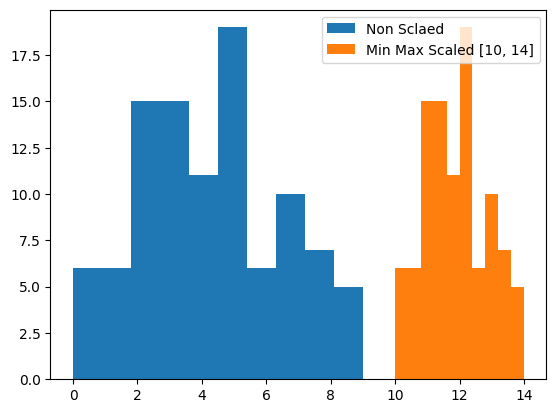

In [ ]:
plt.hist(arr,label="Non Sclaed");
plt.hist(rangeMM, label=f"Min Max Scaled {[a,b]}")
plt.legend();

In [ ]:
# Bounds are now 10 and 14, as requested.
min(rangeMM), max(rangeMM)
# Min = 10 and Max = 14, therefore it confirms that it is scaled

(array([10.]), array([14.]))